In [4]:
import pandas as pd
df = pd.read_csv("ECHO_EXPORTER.csv", low_memory=False)
df = df[df["FAC_STATE"] == "CA"]
df = df[df["SDWIS_FLAG"] == "Y"] # only the drinking water

df['had_enforcement'] = (df['SDWA_FORMAL_ACTION_COUNT'].fillna(0) > 0).astype(int) # is this count greater than 0 - every facility 1 - means it been cited. 
print(df['had_enforcement'].value_counts()) # count how many rows are 1 / 0. how many facilities have enforcement history
print(f"% with enforcement: {df['had_enforcement'].mean()*100:.1f}%") # fraction that are 1, into percentage

print(df.shape)
print(df.columns.tolist()) # display every column name 

had_enforcement
0    14087
1     1854
Name: count, dtype: int64
% with enforcement: 11.6%
(15941, 134)
['REGISTRY_ID', 'FAC_NAME', 'FAC_STREET', 'FAC_CITY', 'FAC_STATE', 'FAC_ZIP', 'FAC_COUNTY', 'FAC_FIPS_CODE', 'FAC_EPA_REGION', 'FAC_INDIAN_CNTRY_FLG', 'FAC_FEDERAL_FLG', 'FAC_US_MEX_BORDER_FLG', 'FAC_CHESAPEAKE_BAY_FLG', 'FAC_NAA_FLAG', 'FAC_LAT', 'FAC_LONG', 'FAC_MAP_ICON', 'FAC_COLLECTION_METHOD', 'FAC_REFERENCE_POINT', 'FAC_ACCURACY_METERS', 'FAC_DERIVED_TRIBES', 'FAC_DERIVED_HUC', 'FAC_DERIVED_WBD', 'FAC_DERIVED_STCTY_FIPS', 'FAC_DERIVED_ZIP', 'FAC_DERIVED_CD113', 'FAC_DERIVED_CB2010', 'FAC_PERCENT_MINORITY', 'FAC_POP_DEN', 'FAC_MAJOR_FLAG', 'FAC_ACTIVE_FLAG', 'FAC_MYRTK_UNIVERSE', 'FAC_INSPECTION_COUNT', 'FAC_DATE_LAST_INSPECTION', 'FAC_DAYS_LAST_INSPECTION', 'FAC_INFORMAL_COUNT', 'FAC_DATE_LAST_INFORMAL_ACTION', 'FAC_FORMAL_ACTION_COUNT', 'FAC_DATE_LAST_FORMAL_ACTION', 'FAC_TOTAL_PENALTIES', 'FAC_PENALTY_COUNT', 'FAC_DATE_LAST_PENALTY', 'FAC_LAST_PENALTY_AMT', 'FAC_QTRS_WITH_NC'

In [ ]:
# New features -- structural/classification info about the facility, not part of
# the drinking-water enforcement process itself, so much lower leakage risk.
df['FAC_MAJOR_FLAG'] = (df['FAC_MAJOR_FLAG'] == 'Y').astype(int)

other_program_flags = ['AIR_FLAG', 'NPDES_FLAG', 'RCRA_FLAG', 'TRI_FLAG', 'GHG_FLAG']
for col in other_program_flags:
    df[col] = (df[col] == 'Y').astype(int)
df['num_other_epa_programs'] = df[other_program_flags].sum(axis=1)

system_type_dummies = pd.get_dummies(df['SDWA_SYSTEM_TYPES'], prefix='sys_type').astype(int)
df = pd.concat([df, system_type_dummies], axis=1)

print(system_type_dummies.columns.tolist())  # sanity check on what categories actually exist

In [ ]:
feature_cols = ['FAC_POP_DEN', 'FAC_INSPECTION_COUNT', 'FAC_DAYS_LAST_INSPECTION',
                 'FAC_MAJOR_FLAG', 'num_other_epa_programs'] + list(system_type_dummies.columns)
# pop den - higher stakes if somethign goes wrong, perc min - higher minor - less attention, inspec - long its been since last, qtrs - how many qrts are out of compliance

X = df[feature_cols]# creates feature matrix
y = df['had_enforcement'] # target tryign to predict 

print(X.isna().sum()) # counts how many missing values in each column 
print(X.describe())

FAC_POP_DEN                 14757
FAC_INSPECTION_COUNT            0
FAC_DAYS_LAST_INSPECTION    15265
dtype: int64
        FAC_POP_DEN  FAC_INSPECTION_COUNT  FAC_DAYS_LAST_INSPECTION
count   1184.000000           15941.00000                676.000000
mean    1737.572635               0.04341               2449.730769
std     2787.041752               0.69394               1828.684603
min        0.000000               0.00000                 24.000000
25%      115.157500               0.00000               1206.000000
50%      569.385000               0.00000               1992.000000
75%     2425.475000               0.00000               3358.250000
max    24470.680000              45.00000              11337.000000


In [ ]:
  %pip install scikit-learn shap

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 11.1 MB 2.5 MB/s eta 0:00:01
     |████████████████████████████████| 556 kB 27.6 MB/s eta 0:00:01
     |████████████████████████████████| 309 kB 52.0 MB/s eta 0:00:01
     |████████████████████████████████| 30.3 MB 47.7 MB/s eta 0:00:01     |███████████▌                    | 10.9 MB 47.7 MB/s eta 0:00:01
     |████████████████████████████████| 2.7 MB 6.2 MB/s eta 0:00:01
     |████████████████████████████████| 80 kB 20.6 MB/s eta 0:00:01
     |████████████████████████████████| 28.8 MB 34.9 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
) # split data into 4, training use 80% of data , stratify 

model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
model.fit(X_train.fillna(0), y_train)

y_pred = model.predict(X_test.fillna(0)) # after trainign predict on x_test, ypred = is its guess
y_prob = model.predict_proba(X_test.fillna(0))[:, 1] # gives models confidence for each facility, provides second number which is the class 1. 

print(classification_report(y_test, y_pred))# compare model guess against true answer y_test
print("ROC-AUC:", roc_auc_score(y_test, y_prob)) #single overall score between 0.5 and 1, using the y_prob

              precision    recall  f1-score   support

           0       0.89      0.98      0.94      2818
           1       0.42      0.10      0.16       371

    accuracy                           0.88      3189
   macro avg       0.66      0.54      0.55      3189
weighted avg       0.84      0.88      0.84      3189

ROC-AUC: 0.4825414786346533


In [8]:
from sklearn.pipeline import Pipeline # chain multiple steps togethe
from sklearn.impute import SimpleImputer # better way to handle missing values 

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42))
])

#the first step is the imputer. instead of replacing missing values with 0, replace missing with median of column less skewed
# second step is the model, same as rf. 

pipeline.fit(X_train, y_train) # runs entire pipeline on trainign data
print("Pipeline ROC-AUC:", roc_auc_score(y_test, pipeline.predict_proba(X_test)[:, 1]))
# runs X_test through the imputer first, then through the trained forest, and returns probability predictions
# grabs the probability of class 1 (had_enforcement) for each row, same as before

Pipeline ROC-AUC: 0.4856094532835698


In [9]:
from sklearn.model_selection import StratifiedKFold, cross_val_score # stratifiedKFold - splitting data into multiple train/tests pairs , cross_val - auto trains and tests the model

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#divides data into 5 folds, train on 4 and then one test and then rotated, so each row gets used as test data
scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
#takes pipeline 
print(f"CV ROC-AUC: {scores.mean():.3f} ± {scores.std():.3f}") #averages the 5 scores and calcaulates the std. small std means the model is consistent. 
#.3f - formatys to both numbers to 3 decimal places

CV ROC-AUC: 0.489 ± 0.007


In [10]:
importance = pd.Series(pipeline.named_steps['model'].feature_importances_, index=feature_cols
).sort_values(ascending=False)
# pipeline calls named_steps to pull out one specific step by name
# model - used the trained RF to get feature importances, which is a number between 0 and 1 for each feature, higher means more important
print(importance)

FAC_POP_DEN                 0.604045
FAC_DAYS_LAST_INSPECTION    0.332571
FAC_INSPECTION_COUNT        0.063384
dtype: float64


/Users/prathyushaparesh/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


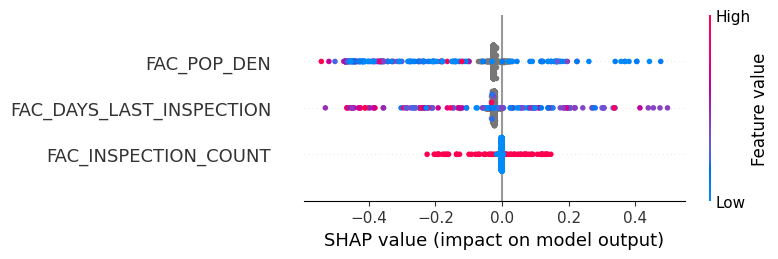

In [11]:
import shap

rf_model = pipeline.named_steps['model']
X_test_imputed = pipeline.named_steps['imputer'].transform(X_test)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_imputed)

shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=feature_cols)

In [12]:
import numpy as np
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(3189, 3, 2)


Facility index: 807
Predicted probability of enforcement: 1.000
FAC_POP_DEN                    NaN
FAC_INSPECTION_COUNT           1.0
FAC_DAYS_LAST_INSPECTION    1649.0
Name: 2823232, dtype: float64


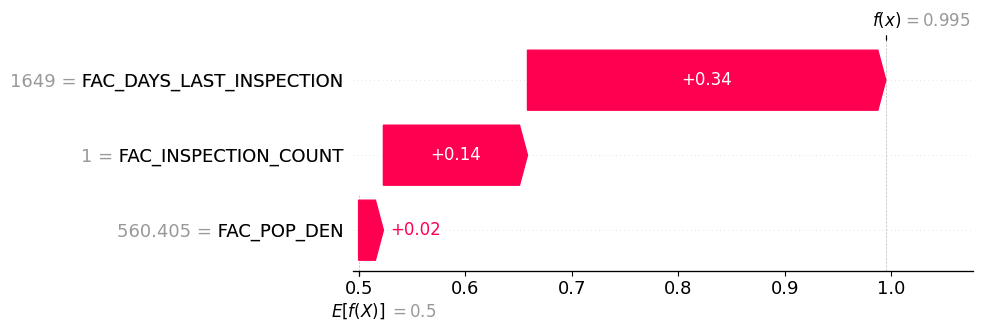

In [13]:
high_risk_idx = np.argmax(y_prob)
print(f"Facility index: {high_risk_idx}")
print(f"Predicted probability of enforcement: {y_prob[high_risk_idx]:.3f}")
print(X_test.iloc[high_risk_idx])

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx, :, 1],
        base_values=explainer.expected_value[1],
        data=X_test_imputed[high_risk_idx],
        feature_names=feature_cols
    )
)

In [14]:
    audit_df = df.loc[X_test.index, ['FAC_PERCENT_MINORITY']].copy()
    audit_df['predicted_prob'] = y_prob
    audit_df['minority_bucket'] = pd.cut(
        audit_df['FAC_PERCENT_MINORITY'].fillna(audit_df['FAC_PERCENT_MINORITY'].median()),
        bins=[0, 25, 50, 75, 100],
        labels=['0-25%', '25-50%', '50-75%', '75-100%']
    )
    print(audit_df.groupby('minority_bucket')['predicted_prob'].mean())

minority_bucket
0-25%      0.226905
25-50%     0.438899
50-75%     0.179479
75-100%    0.161212
Name: predicted_prob, dtype: float64


/var/folders/qk/9_8kvx451rb8jkkpd13j8k0m0000gn/T/ipykernel_81673/3368441580.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(audit_df.groupby('minority_bucket')['predicted_prob'].mean())


In [3]:
import pandas as pd

cols = pd.read_csv("ECHO_EXPORTER.csv", nrows=0).columns.tolist()
pop_cols = [c for c in cols if "POP" in c.upper()]
print(pop_cols)

cols = pd.read_csv("ECHO_EXPORTER.csv", nrows=0).columns.tolist()
join_cols = [c for c in cols if "PWS" in c.upper() or "SDWA" in c.upper()]
print(join_cols)

import pandas as pd

df = pd.read_csv("ECHO_EXPORTER.csv", low_memory=False)
df = df[(df['FAC_STATE'] == 'TX') & (df['FAC_COUNTY'] == 'HARRIS') & (df['SDWIS_FLAG'] == 'Y')]
print(df['SDWA_IDS'].dropna().head(10).tolist())

['FAC_POP_DEN']
['SDWA_IDS', 'SDWA_SYSTEM_TYPES', 'SDWA_INFORMAL_COUNT', 'SDWA_FORMAL_ACTION_COUNT', 'SDWA_COMPLIANCE_STATUS', 'SDWA_SNC_FLAG']
['TX1013145', 'TX1011412', 'TX1011578', 'TX1012227', 'TX1013146', 'TX1013029', 'TX1013018', 'TX1012794', 'TX1010359', 'TX1011872']


In [4]:
# Step 1: pull PWSID cleanly (defensive split in case any row has multiple IDs)
df['PWSID'] = df['SDWA_IDS'].astype(str).str.split(r'[|,]').str[0].str.strip()

# Step 2: load the population file you'd download from
# https://echo.epa.gov/files/echodownloads/SDWA_latest_downloads.zip
# (unzip it, grab SDWA_PUB_WATER_SYSTEMS.csv)
sdwa = pd.read_csv("SDWA_PUB_WATER_SYSTEMS.csv", low_memory=False)
sdwa_tx = sdwa[sdwa['PWSID'].str.startswith('TX', na=False)][['PWSID', 'POPULATION_SERVED_COUNT']]

# Step 3: merge onto your flood-zone-joined dataframe (the one from your
# app.py spatial join that already has REGISTRY_ID + in_flood_zone)
merged = df.merge(sdwa_tx, on='PWSID', how='left')

# Step 4: sum population only for at-risk, SDWIS-flagged, deduped facilities
at_risk = merged[merged['in_flood_zone'] == True]
total_population = at_risk['POPULATION_SERVED_COUNT'].sum()
print(f"Population served by at-risk utilities: {total_population:,.0f}")

FileNotFoundError: [Errno 2] No such file or directory: 'SDWA_PUB_WATER_SYSTEMS.csv'